# Feature Engineering

Using the cleaned Boston 311 dataset (`master_311_clean.csv`) to explore features for a **Random Forest classification** model that predicts whether a neighborhood-month will be **high-risk** for needle pickup activity. The binary target directly supports the policy question: *which neighborhoods need proactive resource allocation?*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Optional dependency used only for basemap overlays.
try:
    import contextily as cx
    HAS_CONTEXTILY = True
except ImportError:
    cx = None
    HAS_CONTEXTILY = False
    print("contextily not installed; map basemap overlays will be skipped.")

sns.set_style("whitegrid")

df = pd.read_csv(Path(".") / "master_311_clean.csv", low_memory=False)

df["open_dt"] = pd.to_datetime(df["open_dt"], errors="coerce")
df["closed_dt"] = pd.to_datetime(df["closed_dt"], errors="coerce")

df["response_hours"] = (df["closed_dt"] - df["open_dt"]).dt.total_seconds() / 3600
df["month"] = df["open_dt"].dt.month
df["day_of_week"] = df["open_dt"].dt.dayofweek
df["is_needle"] = df["type"].str.contains("Needle Pickup", case=False, na=False).astype(int)

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

contextily not installed; map basemap overlays will be skipped.
Shape: (1925881, 18)

Column dtypes:
open_dt                           datetime64[ns]
closed_dt                         datetime64[ns]
case_status                               object
subject                                   object
reason                                    object
type                                      object
neighborhood                              object
neighborhood_services_district            object
ward                                      object
precinct                                  object
latitude                                 float64
longitude                                float64
source                                    object
year                                       int64
response_hours                           float64
month                                      int32
day_of_week                                int32
is_needle                                  int64
dtype: object

Fi

,open_dt,closed_dt,case_status,subject,reason,type,neighborhood,neighborhood_services_district,ward,precinct,latitude,longitude,source,year,response_hours,month,day_of_week,is_needle
0,2018-01-01 00:02:00,2018-01-02 08:05:36,Closed,Public Works Department,Street Cleaning,Request for Snow Plowing (Emergency Responder),Jamaica Plain,10,Ward 19,1912,42.289290,-71.117981,Constituent Call,2018,32.060000,1,0,0
1,2018-01-01 00:46:00,2018-01-01 01:44:28,Closed,Public Works Department,Street Lights,Street Light Knock Downs,Greater Mattapan,13,12,1207,42.302241,-71.087378,Constituent Call,2018,0.974444,1,0,0
2,2018-01-01 01:08:00,2018-02-05 06:03:35,Closed,Boston Water & Sewer Commission,Administrative & General Requests,BWSC General Request,East Boston,1,Ward 1,0106,42.376919,-71.036240,Constituent Call,2018,844.926389,1,0,0


## Univariate Analysis

Distribution of each feature individually: histograms for numeric columns, bar charts for categorical columns.

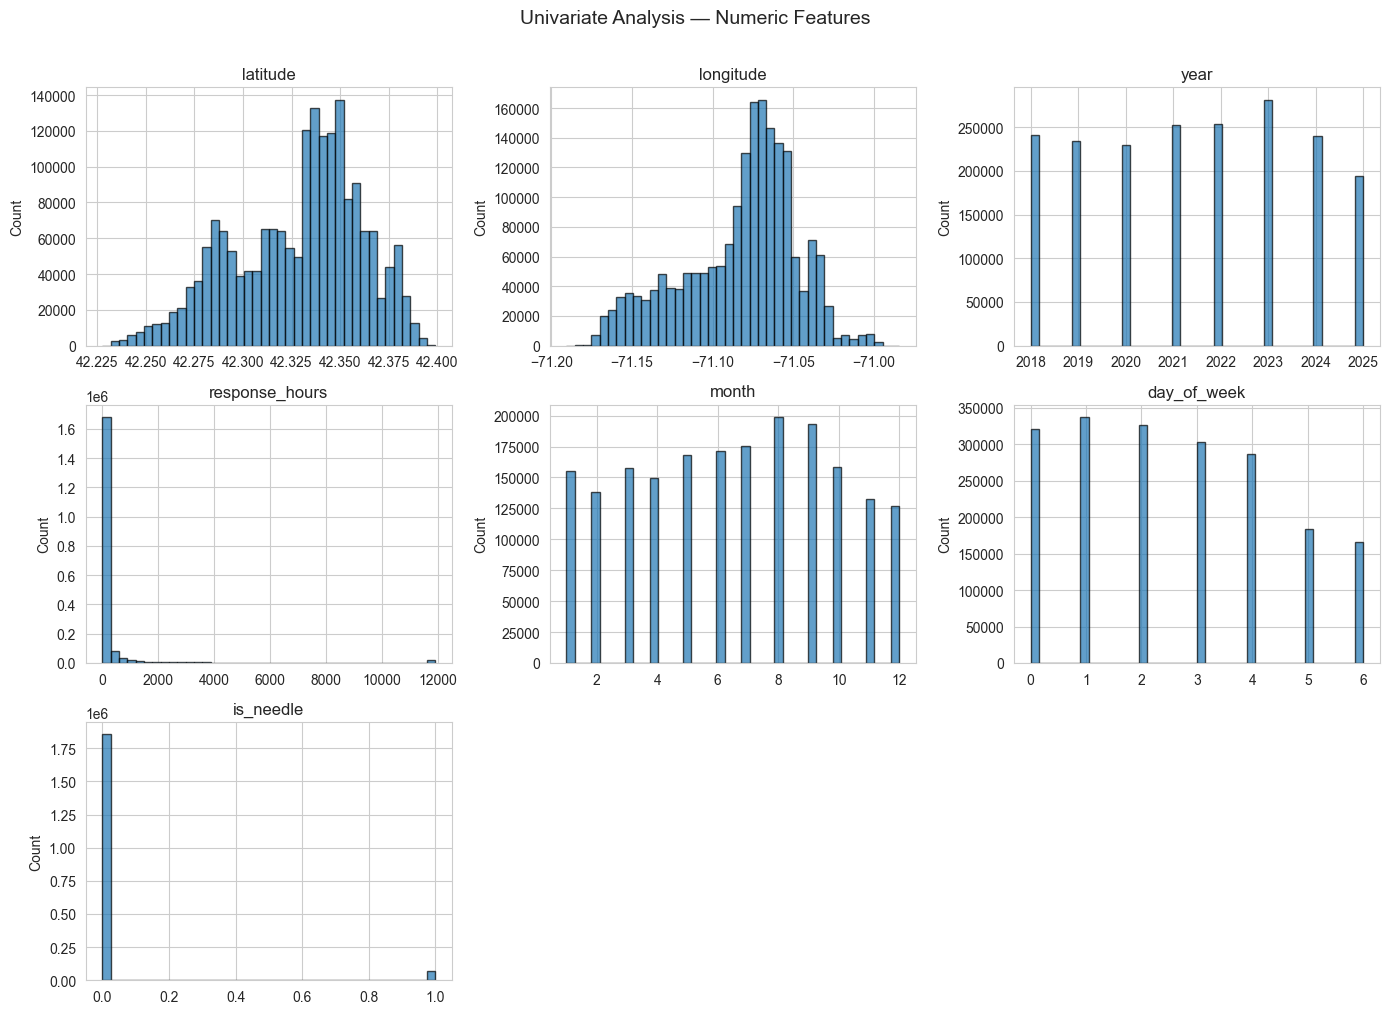

In [5]:
numeric_cols = ["latitude", "longitude", "year", "response_hours", "month", "day_of_week", "is_needle"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    data = df[col].dropna()
    if col == "response_hours":
        data = data.clip(upper=data.quantile(0.99))
    ax.hist(data, bins=40, edgecolor="black", alpha=0.7)
    ax.set_title(col)
    ax.set_ylabel("Count")

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Univariate Analysis — Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Response hours is so right skewed, it may help to remove the outlier.

In [ ]:
cat_cols = ["case_status", "subject", "reason", "type", "neighborhood",
            "neighborhood_services_district", "ward", "source"]

TOP_N = 15

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts().head(TOP_N)
    counts.sort_values().plot.barh(ax=ax, edgecolor="black", alpha=0.7)
    ax.set_title(f"{col}  (top {min(TOP_N, len(counts))})")
    ax.set_xlabel("Count")

fig.suptitle("Univariate Analysis — Categorical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Feature Engineering

### Response Hours — Remove Outliers, Log-Transform, and Neighborhood View

`response_hours` is heavily right-skewed with extreme outliers. We remove rows exceeding 700 hours as outliers, then log-transform the remaining values (`log1p` to handle zeros) to compress the tail. A bar chart of median response time by neighborhood shows whether certain areas consistently experience slower service.

In [ ]:
rows_before = len(df)
outliers_removed = (df["response_hours"] > 700).sum()

df = df[df["response_hours"].isna() | (df["response_hours"] <= 700)].copy()
df["response_hours_log"] = np.log1p(df["response_hours"].clip(lower=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df["response_hours"].dropna(), bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title("response_hours (after removing > 700h)")
axes[0].set_xlabel("Hours")
axes[0].set_ylabel("Count")

axes[1].hist(df["response_hours_log"].dropna(), bins=50, edgecolor="black", alpha=0.7, color="C2")
axes[1].set_title("After log1p transform")
axes[1].set_xlabel("log(1 + hours)")

axes[2].set_visible(False)

plt.suptitle("Response Hours — Before and After Transformation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Rows before: {rows_before:,}")
print(f"Rows removed (> 700h): {outliers_removed:,}")
print(f"Rows after: {len(df):,}")
print(f"\nresponse_hours_log stats:\n{df['response_hours_log'].describe().to_string()}")

In [ ]:
median_resp = (df.dropna(subset=["response_hours"])
               .groupby("neighborhood")["response_hours"]
               .median()
               .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 8))
median_resp.plot.barh(ax=ax, edgecolor="black", alpha=0.7, color="C3")
ax.set_title("Median Response Hours by Neighborhood (outliers > 700h removed)")
ax.set_xlabel("Median Hours")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Multicollinearity — Categorical Features (Cramér's V)

For categorical variables, Pearson correlation does not apply. Instead we use ***Cramér's V***, which measures the strength of association between two categorical variables (0 = no association, 1 = perfect association). Values above ~0.7 suggest redundancy and a candidate for dropping one of the pair.

In [ ]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    v = np.sqrt(chi2 / (n * (min(r, k) - 1))) if min(r, k) > 1 else 0.0
    return v

cat_cols = ["case_status", "subject", "reason", "type", "neighborhood",
            "neighborhood_services_district", "ward", "source"]

sample = df[cat_cols].sample(n=min(50_000, len(df)), random_state=42)

v_matrix = pd.DataFrame(np.zeros((len(cat_cols), len(cat_cols))),
                         index=cat_cols, columns=cat_cols)
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if i <= j:
            val = cramers_v(sample[c1], sample[c2]) if i != j else 1.0
            v_matrix.loc[c1, c2] = val
            v_matrix.loc[c2, c1] = val

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(v_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            square=True, linewidths=0.5, vmin=0, vmax=1, ax=ax)
ax.set_title("Cramér's V — Categorical Feature Association")
plt.tight_layout()
plt.show()

print("\nPairs with Cramér's V > 0.7 (high redundancy):")
for i, c1 in enumerate(cat_cols):
    for j, c2 in enumerate(cat_cols):
        if i < j and v_matrix.loc[c1, c2] > 0.7:
            print(f"  {c1}  ↔  {c2}  :  {v_matrix.loc[c1, c2]:.3f}")

### Temporal Features — Year, Month, and Quarter

We compare three temporal groupings (year, month, quarter) to see which captures the most meaningful variation in needle pickup rate. This informs which temporal feature(s) to include in the final model.

In [ ]:
df["quarter"] = df["open_dt"].dt.quarter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Year
rate_year = df.groupby("year")["is_needle"].mean() * 100
axes[0].bar(rate_year.index.astype(str), rate_year.values, edgecolor="black", alpha=0.7)
axes[0].set_title("Needle Rate (%) by Year")
axes[0].set_ylabel("% of requests")
axes[0].tick_params(axis="x", rotation=45)

# Month
rate_month = df.groupby("month")["is_needle"].mean() * 100
axes[1].bar(rate_month.index.astype(str), rate_month.values, edgecolor="black", alpha=0.7, color="C1")
axes[1].set_title("Needle Rate (%) by Month")
axes[1].set_ylabel("% of requests")

# Quarter
rate_qtr = df.groupby("quarter")["is_needle"].mean() * 100
axes[2].bar(rate_qtr.index.astype(str), rate_qtr.values, edgecolor="black", alpha=0.7, color="C2")
axes[2].set_title("Needle Rate (%) by Quarter")
axes[2].set_ylabel("% of requests")

plt.suptitle("Temporal Grouping Comparison — Needle Rate", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

spread = {
    "Year":    rate_year.max() - rate_year.min(),
    "Month":   rate_month.max() - rate_month.min(),
    "Quarter": rate_qtr.max() - rate_qtr.min(),
}
print("Range of needle rate (%) across levels of each grouping:")
for k, v in spread.items():
    print(f"  {k:>8s}: {v:.2f} pp")

In [ ]:
nbhd_year = (df.groupby(["neighborhood", "year"])
             .agg(needle_count=("is_needle", "sum"),
                  total_requests=("is_needle", "size"))
             .reset_index())
nbhd_year["needle_share"] = nbhd_year["needle_count"] / nbhd_year["total_requests"]

nbhd_year = nbhd_year.sort_values(["neighborhood", "year"])
nbhd_year["needle_count_lag1"] = (nbhd_year.groupby("neighborhood")["needle_count"]
                                   .shift(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid = nbhd_year.dropna(subset=["needle_count_lag1"])

axes[0].scatter(valid["needle_count_lag1"], valid["needle_count"], alpha=0.5, s=30)
axes[0].set_xlabel("Needle Count (prior year)")
axes[0].set_ylabel("Needle Count (current year)")
axes[0].set_title("Lag-1 Feature vs Current Needle Count")
r = valid["needle_count_lag1"].corr(valid["needle_count"])
axes[0].annotate(f"r = {r:.2f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=12)

top_nbhds = nbhd_year.groupby("neighborhood")["needle_count"].sum().nlargest(6).index
for nbhd in top_nbhds:
    sub = nbhd_year[nbhd_year["neighborhood"] == nbhd]
    axes[1].plot(sub["year"], sub["needle_count"], marker="o", label=nbhd)
axes[1].set_title("Needle Count Over Time — Top 6 Neighborhoods")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Needle Count")
axes[1].legend(fontsize=8, loc="upper left")

plt.suptitle("Lag Feature & Neighborhood Trends", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nCorrelation between lag-1 and current needle count: {r:.3f}")
print(f"\nAggregated neighborhood-year table ({len(nbhd_year)} rows):")
nbhd_year.head(10)

### Building the Final Feature Set

We aggregate request-level data to **neighborhood–month** rows and engineer the features the classifier will see. The target is a **binary label** — `high_risk` — indicating whether the needle pickup count for that neighborhood-month exceeds the **75th percentile** across all neighborhood-months.

This aligns directly with the policy question: resource allocation is a discrete decision (deploy crews or not), so a classifier that separates high-risk from low-risk periods is more actionable than a point-count prediction.

**Key decisions:**
- **Drop `type`:** It was used to derive `is_needle` (the target). Including it would leak the answer. `subject` and `reason` describe the department and category of each request — they are safe to include as proportion features per neighborhood-month.
- **Include `source`, `subject`, and `reason` as proportion features:** Each is broken into proportions of key categories per neighborhood-month (e.g., `source_app_pct`, `reason_street_cleaning_pct`). These capture the *mix* of 311 activity in a neighborhood, which signals neighborhood conditions.
- **Exclude neighborhood as a predictor:** Including neighborhood identity would let the model learn "Roxbury is high-risk" without understanding *why*. Dropping it forces the model to predict from observable conditions — producing results that generalize and are interpretable for policy makers. Neighborhood is still used for aggregation and the final risk map.
- **Response-time split features:** `pct_fast_close` (proportion closed within 3 hours) and `median_response_hours_log` capture the bimodal response-time pattern.
- **Temporal feature:** Only `month` is included to capture seasonality (summer peaks, winter dips). No lag or rolling-average features are used, since they are derived from the target variable.

In [ ]:
FAST_CLOSE_THRESHOLD = 3

print("Top source values:")
print(df["source"].value_counts().to_string())
print("\nTop subject values:")
print(df["subject"].value_counts().head(10).to_string())
print("\nTop reason values:")
print(df["reason"].value_counts().head(10).to_string())

agg = (df.groupby(["neighborhood", "year", "month"])
       .agg(
           needle_count=("is_needle", "sum"),
           total_requests=("is_needle", "size"),
           median_response_hours_log=("response_hours_log", "median"),
           pct_fast_close=("response_hours", lambda x: (x <= FAST_CLOSE_THRESHOLD).mean()),
           source_app_pct=("source", lambda x: (x == "Citizens Connect App").mean()),
           source_call_pct=("source", lambda x: (x == "Constituent Call").mean()),
           source_self_pct=("source", lambda x: (x == "Self Service").mean()),
           subject_pwd_pct=("subject", lambda x: (x == "Public Works Department").mean()),
           subject_bwsc_pct=("subject", lambda x: x.str.contains("Boston Water", case=False, na=False).mean()),
           subject_inspections_pct=("subject", lambda x: x.str.contains("Inspectional Services", case=False, na=False).mean()),
           reason_street_cleaning_pct=("reason", lambda x: (x == "Street Cleaning").mean()),
           reason_enforcement_pct=("reason", lambda x: (x == "Enforcement & Abandoned Vehicles").mean()),
           reason_sanitation_pct=("reason", lambda x: x.str.contains("Sanitation", case=False, na=False).mean()),
           reason_housing_pct=("reason", lambda x: x.str.contains("Housing", case=False, na=False).mean()),
           reason_signs_lights_pct=("reason", lambda x: x.isin(["Street Lights", "Signs & Signals"]).mean()),
       )
       .reset_index())

agg["needle_share"] = agg["needle_count"] / agg["total_requests"]

print(f"\nAggregated shape: {agg.shape}")
print(f"Unique neighborhoods: {agg['neighborhood'].nunique()}")
print(f"Year range: {agg['year'].min()} – {agg['year'].max()}")
print(f"\nSample rows:")
agg.head(5)

In [ ]:
print(f"Unique neighborhoods: {agg['neighborhood'].nunique()}")
print(f"\nValue counts:\n{agg['neighborhood'].value_counts().to_string()}")
print("\nNeighborhood is used for aggregation and the risk map,")
print("but excluded from features to avoid location bias.")

In [ ]:
agg = agg.sort_values(["neighborhood", "year", "month"]).reset_index(drop=True)

threshold = agg["needle_count"].quantile(0.75)
agg["high_risk"] = (agg["needle_count"] >= threshold).astype(int)

FEATURE_COLS = [
    "month",
    "total_requests",
    "median_response_hours_log",
    "pct_fast_close",
    "source_app_pct",
    "source_call_pct",
    "source_self_pct",
    "subject_pwd_pct",
    "subject_bwsc_pct",
    "subject_inspections_pct",
    "reason_street_cleaning_pct",
    "reason_enforcement_pct",
    "reason_sanitation_pct",
    "reason_housing_pct",
    "reason_signs_lights_pct",
]
TARGET_COL = "high_risk"

model_df = agg[FEATURE_COLS + [TARGET_COL, "needle_count", "year", "neighborhood"]].dropna().copy()

print(f"High-risk threshold (75th percentile): needle_count >= {threshold:.0f}")
print(f"Class distribution:\n{model_df[TARGET_COL].value_counts().rename({0: 'Low risk', 1: 'High risk'}).to_string()}")
print(f"\nFinal modeling table shape: {model_df.shape}")
print(f"Rows dropped: {len(agg) - len(model_df)}")
print(f"\nFeature columns ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    print(f"  {c}")
print(f"\nTarget: {TARGET_COL}")
print(f"\nDescriptive stats:")
model_df.describe().round(3)

In [ ]:
corr_cols = FEATURE_COLS + [TARGET_COL]
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

corr = model_df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title("Correlation Matrix — Feature Set + Target")

means = model_df.groupby(TARGET_COL)[FEATURE_COLS].mean().T
means.columns = ["Low risk (0)", "High risk (1)"]
means["Difference"] = means["High risk (1)"] - means["Low risk (0)"]
means_sorted = means.sort_values("Difference")

means_sorted["Difference"].plot.barh(ax=axes[1], color=["C0" if v < 0 else "C3" for v in means_sorted["Difference"]],
                                      edgecolor="black", alpha=0.7)
axes[1].set_title("Feature Mean Difference (High Risk − Low Risk)")
axes[1].set_xlabel("Difference in mean value")
axes[1].axvline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()

print("Point-biserial correlation with high_risk:")
print(corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False).to_string())
print("\nFeature means by class:")
print(means.sort_values("Difference", ascending=False).round(4).to_string())

## Random Forest Classification

We use a **time-based train/test split** — training on earlier years and testing on the most recent year — to simulate how the model would perform in a real deployment where policy makers need *forward-looking* predictions of which neighborhoods will be high-risk.

This avoids temporal leakage (the model never sees future data during training) and evaluates on the period most relevant for current resource allocation decisions.

**Maximizing recall** is the priority for this use case: missing a high-risk neighborhood (false negative) means under-allocating cleanup and outreach resources — a more dangerous failure than over-deploying to a neighborhood that turns out to be low-risk (false positive). To achieve this we:
1. **Increase class weight** for the high-risk class (`{0: 1, 1: 4}`), penalizing missed positives more heavily during training.
2. **Remove the depth cap** (`max_depth=None`) to let the trees capture finer-grained splits that distinguish borderline high-risk cases.
3. **Lower the classification threshold** from the default 0.5 by sweeping thresholds on the training set and selecting the one that achieves at least 95% recall.

In [ ]:
SPLIT_YEAR = 2024

train = model_df[model_df["year"] < SPLIT_YEAR]
test = model_df[model_df["year"] >= SPLIT_YEAR]

X_train = train[FEATURE_COLS]
y_train = train[TARGET_COL]
X_test = test[FEATURE_COLS]
y_test = test[TARGET_COL]

print(f"Train: {len(train)} rows  (years < {SPLIT_YEAR})")
print(f"Test:  {len(test)} rows  (years >= {SPLIT_YEAR})")
print(f"Train year range: {train['year'].min()} – {train['year'].max()}")
print(f"Test year range:  {test['year'].min()} – {test['year'].max()}")
print(f"\nTrain class balance: {y_train.value_counts().to_dict()}")
print(f"Test class balance:  {y_test.value_counts().to_dict()}")

clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    min_samples_split=4,
    class_weight={0: 1, 1: 4},
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

y_prob_train = clf.predict_proba(X_train)[:, 1]
y_prob_test = clf.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.30, 0.60, 0.01)
results = []
for t in thresholds:
    preds = (y_prob_train >= t).astype(int)
    r = recall_score(y_train, preds)
    p = precision_score(y_train, preds, zero_division=0)
    f = f1_score(y_train, preds, zero_division=0)
    results.append({"threshold": t, "recall": r, "precision": p, "f1": f})

thresh_df = pd.DataFrame(results)
best_row = thresh_df.loc[thresh_df["recall"].ge(0.95).idxmax()]
BEST_THRESHOLD = best_row["threshold"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", lw=2)
ax.plot(thresh_df["threshold"], thresh_df["f1"], label="F1", lw=2, linestyle="--")
ax.axvline(BEST_THRESHOLD, color="red", linestyle=":", lw=1.5, label=f"Selected threshold = {BEST_THRESHOLD:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Tuning on Training Set (optimizing for recall >= 0.95)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

y_pred_train = (y_prob_train >= BEST_THRESHOLD).astype(int)
y_pred_test = (y_prob_test >= BEST_THRESHOLD).astype(int)

print(f"Model fitted: {clf.n_estimators} trees, max_depth={clf.max_depth}")
print(f"class_weight = {clf.class_weight}")
print(f"\nOptimal threshold (recall >= 0.95 on train): {BEST_THRESHOLD:.2f}")
print(f"At this threshold on train — Recall: {best_row['recall']:.3f}, Precision: {best_row['precision']:.3f}, F1: {best_row['f1']:.3f}")

In [ ]:
metrics = {}
for label, yt, yp in [("Train", y_train, y_pred_train), ("Test", y_test, y_pred_test)]:
    metrics[label] = {
        "Accuracy":  accuracy_score(yt, yp),
        "Precision": precision_score(yt, yp, zero_division=0),
        "Recall":    recall_score(yt, yp, zero_division=0),
        "F1":        f1_score(yt, yp, zero_division=0),
    }

metrics_df = pd.DataFrame(metrics).T
print(f"Classification Metrics (threshold = {BEST_THRESHOLD:.2f})")
print(metrics_df.round(3).to_string())

roc_auc = roc_auc_score(y_test, y_prob_test)
print(f"\nTest ROC-AUC: {roc_auc:.3f}")

print(f"\nClassification Report — Test Set (threshold = {BEST_THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_test, target_names=["Low risk", "High risk"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Low risk", "High risk"],
            yticklabels=["Low risk", "High risk"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix — Test Set (threshold = {BEST_THRESHOLD:.2f})")

fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_test)
axes[1].plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
idx = np.argmin(np.abs(roc_thresholds - BEST_THRESHOLD))
axes[1].scatter(fpr[idx], tpr[idx], color="red", s=100, zorder=5,
                label=f"Operating point (t={BEST_THRESHOLD:.2f})")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Test Set")
axes[1].legend(loc="lower right")

plt.suptitle("Random Forest Classification — Performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax, edgecolor="black", alpha=0.7, color="C2")
ax.set_title("Feature Importance — Random Forest Classifier")
ax.set_xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.show()

print("Feature importances (descending):")
print(importances.sort_values(ascending=False).to_string())

### Predicted Needle Risk — Boston Neighborhood Map

Using the classifier's **predicted probability of high-risk** on the test set, we compute the mean high-risk probability per neighborhood and plot each neighborhood's centroid on a spatial heatmap of Boston. Warmer/larger dots indicate neighborhoods the model identifies as consistently high-risk — directly telling policy makers where to prioritize cleanup crews and outreach.

In [ ]:
centroids = (df.groupby("neighborhood")
             .agg(lat=("latitude", "mean"), lon=("longitude", "mean"))
             .reset_index())

test_with_nbhd = test.copy()
test_with_nbhd["predicted_class"] = y_pred_test
test_with_nbhd["risk_prob"] = y_prob_test

risk = (test_with_nbhd.groupby("neighborhood")
        .agg(mean_risk_prob=("risk_prob", "mean"),
             pct_flagged=("predicted_class", "mean"),
             actual_high_risk_pct=("high_risk", "mean"),
             mean_needle_count=("needle_count", "mean"))
        .reset_index())

risk = risk.merge(centroids, on="neighborhood", how="left")

def lonlat_to_webmercator(lon, lat):
    x = lon * 20037508.34 / 180
    y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
    y = y * 20037508.34 / 180
    return x, y

risk["x"], risk["y"] = lonlat_to_webmercator(risk["lon"].values, risk["lat"].values)

fig, ax = plt.subplots(figsize=(12, 12))

scatter = ax.scatter(
    risk["x"], risk["y"],
    c=risk["mean_risk_prob"],
    s=risk["mean_risk_prob"] * 300 + 40,
    cmap="YlOrRd",
    edgecolors="black",
    linewidths=0.6,
    alpha=0.85,
    zorder=5,
    vmin=0, vmax=1,
)

for _, row in risk.iterrows():
    ax.annotate(
        row["neighborhood"],
        (row["x"], row["y"]),
        fontsize=7,
        fontweight="bold",
        ha="center",
        va="bottom",
        xytext=(0, 8),
        textcoords="offset points",
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
    )

PAD = 1500
ax.set_xlim(risk["x"].min() - PAD, risk["x"].max() + PAD)
ax.set_ylim(risk["y"].min() - PAD, risk["y"].max() + PAD)

if HAS_CONTEXTILY:
    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, zoom=13)
else:
    ax.set_facecolor("#f3f4f6")
    print("Basemap skipped because contextily is not installed.")

cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Mean Predicted High-Risk Probability", fontsize=11)

ax.set_title("Predicted Needle Pickup Risk by Neighborhood — Test Period", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print("Neighborhood risk ranking (test period, descending):")
print(risk[["neighborhood", "mean_risk_prob", "pct_flagged", "actual_high_risk_pct", "mean_needle_count"]]
      .sort_values("mean_risk_prob", ascending=False)
      .round(3)
      .to_string(index=False))

### Model Results — Interpretation

**Why maximize recall?** In a public health resource allocation context, the cost of a **false negative** (missing a high-risk neighborhood) far exceeds the cost of a **false positive** (deploying to a neighborhood that turns out to be low-risk). Missing a hotspot means needles remain on streets, creating health hazards. Over-deploying is a minor efficiency cost.

**Metrics breakdown:**
- **Recall** is the primary metric. It answers: "Of the neighborhood-months that truly were high-risk, what proportion did we catch?" By tuning the classification threshold and increasing the class weight for the positive class, we prioritize catching as many true high-risk periods as possible.
- **Precision** answers: "Of the neighborhood-months we flagged as high-risk, what proportion actually were?" With a lowered threshold, precision decreases — we accept more false alarms — but the trade-off is justified for public safety.
- **F1 Score** balances both, but in this application recall matters more than the balanced F1 would suggest.
- **ROC-AUC** measures the model's ranking ability across all thresholds. A value near 1.0 confirms the model has strong discriminative signal regardless of where the threshold is set.

**Threshold tuning:** Rather than using the default 0.5 cutoff, we swept thresholds on the training set and selected the lowest threshold that achieves at least 95% recall. This ensures the model errs on the side of caution — flagging borderline cases rather than missing them.

**Train vs Test gap:** Some gap is expected since the model is trained on 2018–2022 and tested on 2024–2025, and needle patterns may have shifted. The key question is whether test recall remains high — indicating the model generalizes its recall-oriented behavior to unseen future data.

**Feature importance:** Shows which features the Random Forest relies on most for its splits. With no neighborhood identity, lag, or rolling-average features, the model must learn entirely from observable conditions — `month`, `total_requests`, response-time characteristics, and the `source`/`subject`/`reason` proportions — producing actionable insights about what conditions distinguish high-risk from low-risk neighborhood-months, independent of location.

**Confusion matrix:** The four quadrants show: true negatives (correctly identified low-risk), false positives (falsely flagged as high-risk), false negatives (missed high-risk — the most dangerous for policy), and true positives (correctly caught high-risk).

**Risk map:** The spatial heatmap translates the classifier's predicted probabilities into the visual language policy makers use — neighborhoods with larger, redder dots have a higher predicted probability of being high-risk and need more cleanup crews, outreach workers, and disposal infrastructure. This directly answers the research question: *Can high-risk locations be predicted in advance to support proactive resource allocation?*

## Spike Detection for Needle Pickup Hotspots

Goal: detect anomalous weekly surges in needle pickup requests by neighborhood.

Pipeline:
1. Build a balanced weekly panel for every neighborhood.
2. Create a local rolling baseline and define spike labels.
3. Train a baseline model and a neural-network model.
4. Evaluate with precision/recall/F1 to prioritize practical alerting performance.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix

# Rebuild a robust needle flag in case prior cells were run out of order.
needle_mask = (
    df["reason"].astype(str).str.contains("Needle", case=False, na=False)
    | df["type"].astype(str).str.contains("Needle", case=False, na=False)
    | df["subject"].astype(str).str.contains("Needle", case=False, na=False)
)

needle_df = df.loc[needle_mask, ["open_dt", "neighborhood", "latitude", "longitude"]].copy()
needle_df = needle_df.dropna(subset=["open_dt", "neighborhood"])
needle_df["week_start"] = needle_df["open_dt"].dt.to_period("W").dt.start_time

print(f"Needle rows for modeling: {len(needle_df):,}")
print(f"Neighborhoods covered: {needle_df['neighborhood'].nunique()}")
print(f"Week range: {needle_df['week_start'].min().date()} to {needle_df['week_start'].max().date()}")

Needle rows for modeling: 71,241
Neighborhoods covered: 24
Week range: 2018-01-01 to 2025-12-29


In [7]:
# 1) Build complete neighborhood-week panel (includes zero-incident weeks)
weekly_counts = (
    needle_df.groupby(["neighborhood", "week_start"]).size().rename("needle_count").reset_index()
)

all_neighborhoods = np.sort(weekly_counts["neighborhood"].unique())
all_weeks = pd.date_range(
    weekly_counts["week_start"].min(),
    weekly_counts["week_start"].max(),
    freq="W-MON"
)

panel_index = pd.MultiIndex.from_product(
    [all_neighborhoods, all_weeks],
    names=["neighborhood", "week_start"]
)

panel = (
    weekly_counts
    .set_index(["neighborhood", "week_start"])
    .reindex(panel_index, fill_value=0)
    .reset_index()
    .sort_values(["neighborhood", "week_start"])
    .reset_index(drop=True)
)

print(f"Panel rows: {len(panel):,}")
print(f"Neighborhoods: {panel['neighborhood'].nunique()}")
print(f"Weeks: {panel['week_start'].nunique()}")
print(panel.head())

Panel rows: 10,032
Neighborhoods: 24
Weeks: 418
  neighborhood week_start  needle_count
0              2018-01-01             0
1              2018-01-08             1
2              2018-01-15             0
3              2018-01-22             0
4              2018-01-29             0


In [8]:
# 2) Create rolling baseline + spike label
ROLL_WINDOW = 8
SPIKE_STD_MULT = 1.5

panel["rolling_mean_8"] = (
    panel.groupby("neighborhood")["needle_count"]
    .transform(lambda s: s.shift(1).rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).mean())
)
panel["rolling_std_8"] = (
    panel.groupby("neighborhood")["needle_count"]
    .transform(lambda s: s.shift(1).rolling(ROLL_WINDOW, min_periods=ROLL_WINDOW).std())
)
panel["rolling_std_8"] = panel["rolling_std_8"].fillna(0.0)

panel["spike_threshold"] = panel["rolling_mean_8"] + SPIKE_STD_MULT * panel["rolling_std_8"]
panel["is_spike"] = (
    (panel["rolling_mean_8"].notna())
    & (panel["needle_count"] > panel["spike_threshold"])
).astype(int)

model_df = panel.dropna(subset=["rolling_mean_8"]).copy()

print("Spike label distribution:")
print(model_df["is_spike"].value_counts().to_string())
print(f"Spike rate: {model_df['is_spike'].mean():.3%}")
print(model_df[["needle_count", "rolling_mean_8", "rolling_std_8", "spike_threshold", "is_spike"]].head())

Spike label distribution:
is_spike
0    8665
1    1175
Spike rate: 11.941%
    needle_count  rolling_mean_8  rolling_std_8  spike_threshold  is_spike
8              0           0.125       0.353553          0.65533         0
9              1           0.125       0.353553          0.65533         1
10             0           0.125       0.353553          0.65533         0
11             0           0.125       0.353553          0.65533         0
12             0           0.125       0.353553          0.65533         0


In [9]:
# 3) Feature engineering for forecasting-like spike detection
LAGS = [1, 2, 3, 4, 8]

for lag in LAGS:
    model_df[f"lag_{lag}"] = model_df.groupby("neighborhood")["needle_count"].shift(lag)

model_df["roll_mean_4"] = (
    model_df.groupby("neighborhood")["needle_count"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=4).mean())
)
model_df["roll_std_4"] = (
    model_df.groupby("neighborhood")["needle_count"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=4).std())
)

model_df["month"] = model_df["week_start"].dt.month
model_df["weekofyear"] = model_df["week_start"].dt.isocalendar().week.astype(int)

feature_cols = [
    "rolling_mean_8", "rolling_std_8", "roll_mean_4", "roll_std_4", "month", "weekofyear"
] + [f"lag_{lag}" for lag in LAGS]

target_col = "is_spike"

model_df = model_df.dropna(subset=feature_cols).copy()
print(f"Rows after lag feature creation: {len(model_df):,}")
print("Feature columns:", feature_cols)

Rows after lag feature creation: 9,648
Feature columns: ['rolling_mean_8', 'rolling_std_8', 'roll_mean_4', 'roll_std_4', 'month', 'weekofyear', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8']


In [10]:
# 4) Time-based split (train on earlier weeks, test on latest period)
TEST_START = pd.Timestamp("2024-01-01")

train_df = model_df[model_df["week_start"] < TEST_START].copy()
test_df = model_df[model_df["week_start"] >= TEST_START].copy()

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print(f"Train range: {train_df['week_start'].min().date()} -> {train_df['week_start'].max().date()}")
print(f"Test range:  {test_df['week_start'].min().date()} -> {test_df['week_start'].max().date()}")
print("\nClass balance")
print("Train:", y_train.value_counts().to_dict())
print("Test :", y_test.value_counts().to_dict())

Train rows: 7,128 | Test rows: 2,520
Train range: 2018-04-23 -> 2023-12-25
Test range:  2024-01-01 -> 2025-12-29

Class balance
Train: {0: 6269, 1: 859}
Test : {0: 2229, 1: 291}


In [11]:
# 5) Baseline and neural-network models
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=400,
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
nn_pred = nn_model.predict(X_test)

/Users/eugeneho/anaconda3/envs/vsc-py311/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


In [12]:
# 6) Evaluation focused on spike-alert performance

def summarize_results(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {name} ===")
    print(f"Precision: {p:.3f}")
    print(f"Recall:    {r:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print("Confusion matrix [ [TN, FP], [FN, TP] ]:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

summarize_results("Logistic Baseline", y_test, baseline_pred)
summarize_results("Neural Network (MLP)", y_test, nn_pred)


=== Logistic Baseline ===
Precision: 0.138
Recall:    0.632
F1-score:  0.226
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[1078 1151]
 [ 107  184]]

Classification report:
              precision    recall  f1-score   support

           0      0.910     0.484     0.632      2229
           1      0.138     0.632     0.226       291

    accuracy                          0.501      2520
   macro avg      0.524     0.558     0.429      2520
weighted avg      0.821     0.501     0.585      2520


=== Neural Network (MLP) ===
Precision: 0.375
Recall:    0.072
F1-score:  0.121
Confusion matrix [ [TN, FP], [FN, TP] ]:
[[2194   35]
 [ 270   21]]

Classification report:
              precision    recall  f1-score   support

           0      0.890     0.984     0.935      2229
           1      0.375     0.072     0.121       291

    accuracy                          0.879      2520
   macro avg      0.633     0.528     0.528      2520
weighted avg      0.831     0.879     0.841      2520



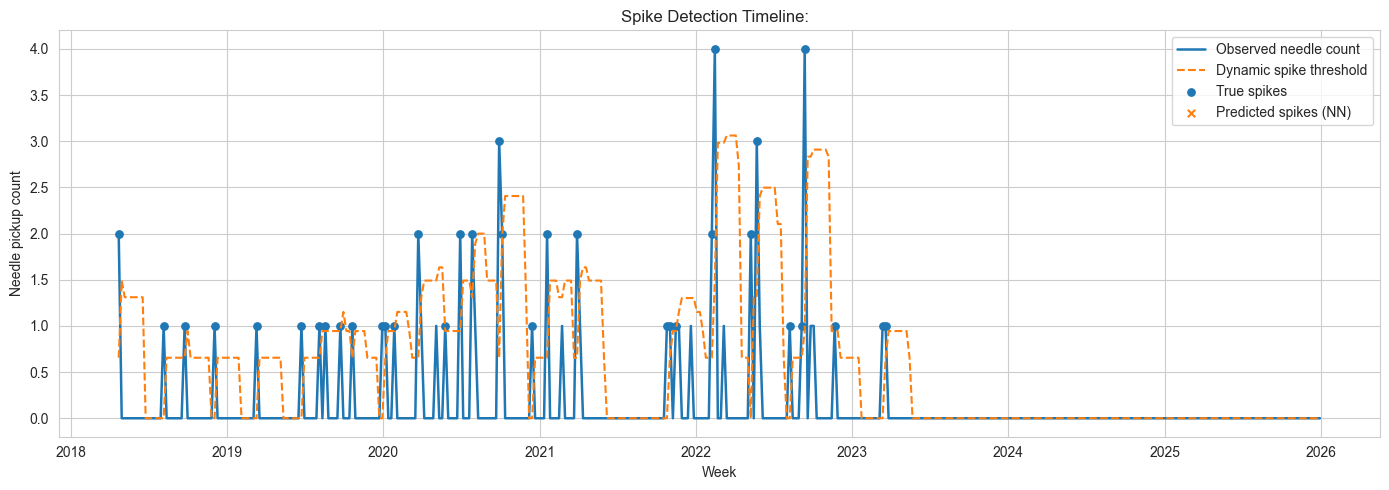

In [13]:
# 7) Visual check: observed counts, threshold, and spike predictions for one neighborhood
example_nbhd = model_df["neighborhood"].value_counts().index[0]
plot_df = model_df[model_df["neighborhood"] == example_nbhd].copy()

# Attach model predictions only where test period exists.
plot_df = plot_df.merge(
    test_df[["neighborhood", "week_start"]].assign(
        pred_baseline=baseline_pred,
        pred_nn=nn_pred
    ),
    on=["neighborhood", "week_start"],
    how="left"
)

plt.figure(figsize=(14, 5))
plt.plot(plot_df["week_start"], plot_df["needle_count"], label="Observed needle count", linewidth=1.8)
plt.plot(plot_df["week_start"], plot_df["spike_threshold"], label="Dynamic spike threshold", linestyle="--")

spikes_true = plot_df[plot_df["is_spike"] == 1]
plt.scatter(spikes_true["week_start"], spikes_true["needle_count"], s=28, label="True spikes")

spikes_nn = plot_df[(plot_df["pred_nn"] == 1)]
plt.scatter(spikes_nn["week_start"], spikes_nn["needle_count"], s=28, marker="x", label="Predicted spikes (NN)")

plt.title(f"Spike Detection Timeline: {example_nbhd}")
plt.xlabel("Week")
plt.ylabel("Needle pickup count")
plt.legend()
plt.tight_layout()
plt.show()

### Next Iterations

- Tune spike threshold sensitivity (`SPIKE_STD_MULT`) to trade off recall vs false alarms.
- Replace MLP with sequence models (LSTM/Temporal CNN) for richer temporal dynamics. **Selected:** Temporal CNN.
- Add spatial lag features from adjacent neighborhoods for hotspot spillover effects.
- Evaluate by "alerts per month" and "detected true spikes" for policy-facing interpretability.

### Iteration 1: Temporal CNN for Spike Detection

This experiment replaces the MLP with a 1D convolutional network over each neighborhood's recent weekly needle-count history.

- Input sequence: last 8 weeks of `needle_count`
- Target: current-week `is_spike`
- Split: train `< 2024-01-01`, test `>= 2024-01-01` (same deployment-style holdout)

This keeps the evaluation comparable while giving the model temporal pattern capacity (local trend/shape detection).

In [15]:
# Temporal CNN dependencies (run once in this kernel)
# If this cell errors, install TensorFlow in your active environment:
%pip install tensorflow

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.4/223.4 MB 12.4 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 49.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.8 M

In [16]:
# Build supervised sequences from panel data and train Temporal CNN
SEQ_LEN = 8
TEST_START = pd.Timestamp("2024-01-01")

seq_df = panel.copy()
seq_df = seq_df.sort_values(["neighborhood", "week_start"]).reset_index(drop=True)

# Label each row using the same rolling-threshold definition
seq_df["rolling_mean_8"] = (
    seq_df.groupby("neighborhood")["needle_count"]
    .transform(lambda s: s.shift(1).rolling(8, min_periods=8).mean())
)
seq_df["rolling_std_8"] = (
    seq_df.groupby("neighborhood")["needle_count"]
    .transform(lambda s: s.shift(1).rolling(8, min_periods=8).std())
    .fillna(0.0)
)
seq_df["spike_threshold"] = seq_df["rolling_mean_8"] + SPIKE_STD_MULT * seq_df["rolling_std_8"]
seq_df["is_spike"] = (
    (seq_df["rolling_mean_8"].notna())
    & (seq_df["needle_count"] > seq_df["spike_threshold"])
).astype(int)

X_seq, y_seq, wk_seq, nbhd_seq = [], [], [], []
for nbhd, g in seq_df.groupby("neighborhood"):
    g = g.sort_values("week_start").reset_index(drop=True)
    counts = g["needle_count"].to_numpy(dtype=np.float32)
    labels = g["is_spike"].to_numpy(dtype=np.int32)
    weeks = g["week_start"].to_numpy()

    for t in range(SEQ_LEN, len(g)):
        # Use previous SEQ_LEN weeks to predict spike at week t
        X_seq.append(counts[t-SEQ_LEN:t].reshape(SEQ_LEN, 1))
        y_seq.append(labels[t])
        wk_seq.append(weeks[t])
        nbhd_seq.append(nbhd)

X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.int32)
wk_seq = pd.to_datetime(pd.Series(wk_seq))

train_mask = wk_seq < TEST_START
test_mask = wk_seq >= TEST_START

X_train_cnn, y_train_cnn = X_seq[train_mask.values], y_seq[train_mask.values]
X_test_cnn, y_test_cnn = X_seq[test_mask.values], y_seq[test_mask.values]

print(f"Temporal CNN train sequences: {len(X_train_cnn):,}")
print(f"Temporal CNN test sequences:  {len(X_test_cnn):,}")
print("Train class balance:", pd.Series(y_train_cnn).value_counts().to_dict())
print("Test class balance: ", pd.Series(y_test_cnn).value_counts().to_dict())

# Handle class imbalance to improve spike recall
neg = max((y_train_cnn == 0).sum(), 1)
pos = max((y_train_cnn == 1).sum(), 1)
class_weight = {0: 1.0, 1: float(neg / pos)}
print("Class weights:", class_weight)

cnn = models.Sequential([
    layers.Input(shape=(SEQ_LEN, 1)),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal"),
    layers.Conv1D(filters=32, kernel_size=3, activation="relu", padding="causal"),
    layers.GlobalMaxPooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

early_stop = callbacks.EarlyStopping(
    monitor="val_recall",
    mode="max",
    patience=8,
    restore_best_weights=True
)

history = cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_split=0.2,
    epochs=60,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

y_prob_cnn = cnn.predict(X_test_cnn, verbose=0).ravel()

# Keep same default threshold for initial CNN comparison
y_pred_cnn = (y_prob_cnn >= 0.5).astype(int)

summarize_results("Temporal CNN", y_test_cnn, y_pred_cnn)

print("\nCNN probability summary (test):")
print(pd.Series(y_prob_cnn).describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(4))

Temporal CNN train sequences: 7,320
Temporal CNN test sequences:  2,520
Train class balance: {0: 6436, 1: 884}
Test class balance:  {0: 2229, 1: 291}
Class weights: {0: 1.0, 1: 7.280542986425339}
Epoch 1/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.2084 - precision: 0.1351 - recall: 0.2801 - val_loss: 0.5805 - val_precision: 0.1828 - val_recall: 0.3487
Epoch 2/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1893 - precision: 0.1456 - recall: 0.4993 - val_loss: 0.5144 - val_precision: 0.1791 - val_recall: 0.2462
Epoch 3/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1869 - precision: 0.1498 - recall: 0.4993 - val_loss: 0.5391 - val_precision: 0.1850 - val_recall: 0.3795
Epoch 4/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1776 - precision: 0.1547 - recall: 0.5806 - val_loss: 0.6694 - val_precision: 0.1557 - val_recall: 0.7026
Epoch 5/60
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1782 - precision: 0.1590 - recall: 0.6052 - val_loss: 0.6599 - val_precision: 0.

### Iteration 2: Tune `SPIKE_STD_MULT` Label Sensitivity

This sweep changes spike-label strictness in the rule:

`is_spike = needle_count > rolling_mean_8 + SPIKE_STD_MULT * rolling_std_8`

Lower multipliers produce more positive labels (higher recall potential, more false alarms). Higher multipliers produce fewer positive labels (cleaner alerts, higher miss risk).

Label sensitivity sweep results:


,SPIKE_STD_MULT,overall_spike_rate,train_spike_rate,test_spike_rate,test_precision,test_recall,test_f1,test_fp,test_fn,test_tp,test_alerts
0,1.000000,17.34%,17.42%,17.10%,0.211,0.596,0.312,962,174,257,1219
1,1.250000,13.84%,13.97%,13.45%,0.163,0.614,0.258,1065,131,208,1273
2,1.500000,11.92%,12.05%,11.55%,0.138,0.632,0.226,1151,107,184,1335
3,1.750000,9.58%,9.72%,9.17%,0.114,0.662,0.194,1195,78,153,1348
4,2.000000,8.16%,8.31%,7.74%,0.101,0.677,0.176,1172,63,132,1304
5,2.500000,5.52%,5.64%,5.20%,0.080,0.733,0.145,1097,35,96,1193


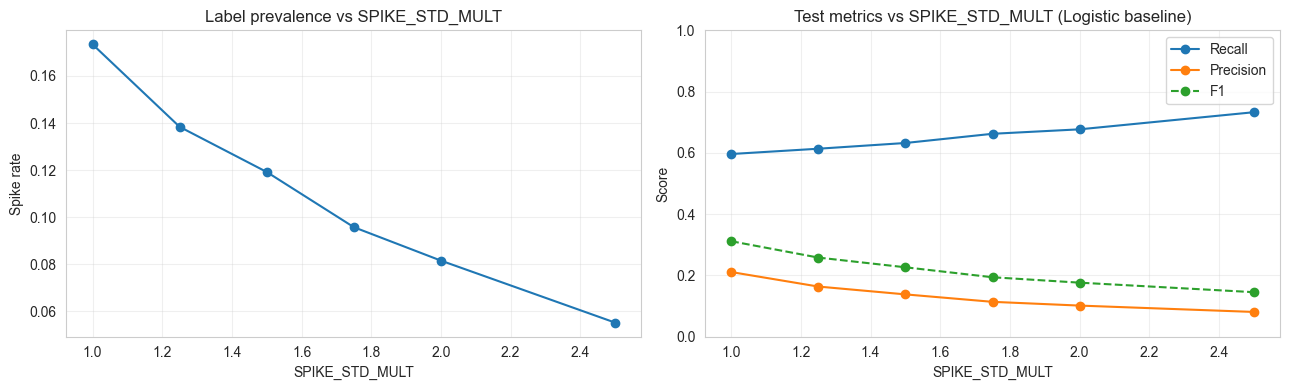

Highest recall setting: SPIKE_STD_MULT=2.50 | Recall=0.733 | Precision=0.080
Highest F1 setting:     SPIKE_STD_MULT=1.00 | F1=0.312 | Recall=0.596


In [17]:
# Sweep SPIKE_STD_MULT and evaluate downstream model behavior
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

std_mult_grid = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5]
TEST_START = pd.Timestamp("2024-01-01")
LAGS = [1, 2, 3, 4, 8]

rows = []

for mult in std_mult_grid:
    temp = panel.copy().sort_values(["neighborhood", "week_start"]).reset_index(drop=True)

    temp["rolling_mean_8"] = (
        temp.groupby("neighborhood")["needle_count"]
        .transform(lambda s: s.shift(1).rolling(8, min_periods=8).mean())
    )
    temp["rolling_std_8"] = (
        temp.groupby("neighborhood")["needle_count"]
        .transform(lambda s: s.shift(1).rolling(8, min_periods=8).std())
    ).fillna(0.0)

    temp["spike_threshold"] = temp["rolling_mean_8"] + mult * temp["rolling_std_8"]
    temp["is_spike"] = (
        (temp["rolling_mean_8"].notna())
        & (temp["needle_count"] > temp["spike_threshold"])
    ).astype(int)

    model_temp = temp.dropna(subset=["rolling_mean_8"]).copy()

    for lag in LAGS:
        model_temp[f"lag_{lag}"] = model_temp.groupby("neighborhood")["needle_count"].shift(lag)

    model_temp["roll_mean_4"] = (
        model_temp.groupby("neighborhood")["needle_count"]
        .transform(lambda s: s.shift(1).rolling(4, min_periods=4).mean())
    )
    model_temp["roll_std_4"] = (
        model_temp.groupby("neighborhood")["needle_count"]
        .transform(lambda s: s.shift(1).rolling(4, min_periods=4).std())
    )

    model_temp["month"] = model_temp["week_start"].dt.month
    model_temp["weekofyear"] = model_temp["week_start"].dt.isocalendar().week.astype(int)

    feature_cols = [
        "rolling_mean_8", "rolling_std_8", "roll_mean_4", "roll_std_4", "month", "weekofyear"
    ] + [f"lag_{lag}" for lag in LAGS]

    model_temp = model_temp.dropna(subset=feature_cols).copy()

    train_df = model_temp[model_temp["week_start"] < TEST_START].copy()
    test_df = model_temp[model_temp["week_start"] >= TEST_START].copy()

    X_train, y_train = train_df[feature_cols], train_df["is_spike"]
    X_test, y_test = test_df[feature_cols], test_df["is_spike"]

    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "SPIKE_STD_MULT": mult,
        "overall_spike_rate": model_temp["is_spike"].mean(),
        "train_spike_rate": y_train.mean(),
        "test_spike_rate": y_test.mean(),
        "test_precision": p,
        "test_recall": r,
        "test_f1": f1,
        "test_fp": int(fp),
        "test_fn": int(fn),
        "test_tp": int(tp),
        "test_alerts": int((y_pred == 1).sum())
    })

sweep_df = pd.DataFrame(rows).sort_values("SPIKE_STD_MULT")

print("Label sensitivity sweep results:")
display(
    sweep_df.style.format({
        "overall_spike_rate": "{:.2%}",
        "train_spike_rate": "{:.2%}",
        "test_spike_rate": "{:.2%}",
        "test_precision": "{:.3f}",
        "test_recall": "{:.3f}",
        "test_f1": "{:.3f}"
    })
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(sweep_df["SPIKE_STD_MULT"], sweep_df["overall_spike_rate"], marker="o")
axes[0].set_title("Label prevalence vs SPIKE_STD_MULT")
axes[0].set_xlabel("SPIKE_STD_MULT")
axes[0].set_ylabel("Spike rate")
axes[0].grid(alpha=0.3)

axes[1].plot(sweep_df["SPIKE_STD_MULT"], sweep_df["test_recall"], marker="o", label="Recall")
axes[1].plot(sweep_df["SPIKE_STD_MULT"], sweep_df["test_precision"], marker="o", label="Precision")
axes[1].plot(sweep_df["SPIKE_STD_MULT"], sweep_df["test_f1"], marker="o", linestyle="--", label="F1")
axes[1].set_title("Test metrics vs SPIKE_STD_MULT (Logistic baseline)")
axes[1].set_xlabel("SPIKE_STD_MULT")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_recall_row = sweep_df.sort_values(["test_recall", "test_precision"], ascending=[False, False]).iloc[0]
best_f1_row = sweep_df.sort_values(["test_f1", "test_recall"], ascending=[False, False]).iloc[0]

print(f"Highest recall setting: SPIKE_STD_MULT={best_recall_row['SPIKE_STD_MULT']:.2f} | Recall={best_recall_row['test_recall']:.3f} | Precision={best_recall_row['test_precision']:.3f}")
print(f"Highest F1 setting:     SPIKE_STD_MULT={best_f1_row['SPIKE_STD_MULT']:.2f} | F1={best_f1_row['test_f1']:.3f} | Recall={best_f1_row['test_recall']:.3f}")

### Iteration 3: Temporal CNN Probability-Threshold Sweep

With label definition fixed, this step tunes the **decision threshold** on CNN probabilities to balance:

- spike recall
- false alarms (precision)
- operational load (`alerts per month`)

This directly supports policy deployment choices.

Temporal CNN threshold sweep results:


/var/folders/dh/hkh75hpx7wl4_kk9fm7gkwsm0000gn/T/ipykernel_59773/4292891717.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: int(((g["y_true"] == 1) & (g["y_pred"] == 1)).sum()))
/var/folders/dh/hkh75hpx7wl4_kk9fm7gkwsm0000gn/T/ipykernel_59773/4292891717.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: int(((g["y_true"] == 1) & (g["y_pred"] == 1)).sum()))
/var/folders/dh/hkh7

,threshold,precision,recall,f1,fp,fn,tp,alerts_total,alerts_per_month_avg,alerts_per_month_p90,true_spikes_detected_per_month_avg
0,0.10,0.116,1.000,0.207,2227,0,291,2518,104.9,120.0,12.1
1,0.15,0.116,1.000,0.208,2218,0,291,2509,104.5,120.0,12.1
2,0.20,0.116,1.000,0.208,2212,0,291,2503,104.3,120.0,12.1
3,0.25,0.116,0.997,0.208,2201,1,290,2491,103.8,120.0,12.1
4,0.30,0.117,0.993,0.209,2183,2,289,2472,103.0,118.7,12.0
5,0.35,0.118,0.993,0.211,2160,2,289,2449,102.0,118.0,12.0
6,0.40,0.130,0.924,0.229,1793,22,269,2062,85.9,101.7,11.2
7,0.45,0.135,0.921,0.236,1712,23,268,1980,82.5,98.8,11.2
8,0.50,0.139,0.880,0.240,1585,35,256,1841,76.7,90.7,10.7
9,0.55,0.149,0.835,0.253,1384,48,243,1627,67.8,82.8,10.1


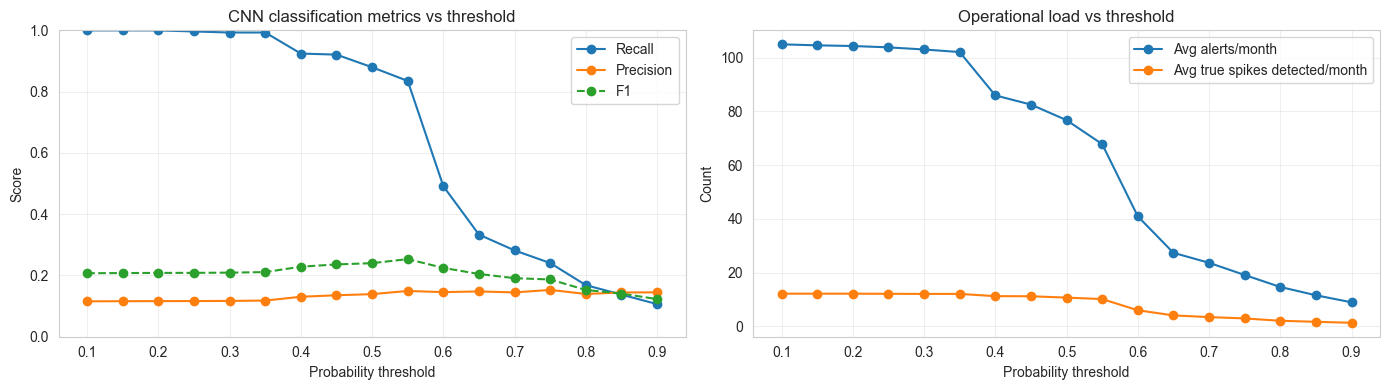

Best recall threshold: 0.20 | Recall=1.000, Precision=0.116, Avg alerts/month=104.3
Best F1 threshold:     0.55 | F1=0.253, Recall=0.835, Avg alerts/month=67.8
Best threshold under budget (40 alerts/month): 0.65 | Recall=0.333, Precision=0.148


In [18]:
# Sweep CNN probability thresholds and evaluate operational metrics
# Requires prior Temporal CNN cell outputs: y_test_cnn, y_prob_cnn, wk_seq, test_mask

from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

threshold_grid = np.round(np.arange(0.10, 0.91, 0.05), 2)

# Align test-period week index to CNN test labels
wk_test_cnn = pd.to_datetime(wk_seq[test_mask.values].reset_index(drop=True))

rows = []
for t in threshold_grid:
    pred = (y_prob_cnn >= t).astype(int)

    p, r, f1, _ = precision_recall_fscore_support(y_test_cnn, pred, average="binary", zero_division=0)
    cm = confusion_matrix(y_test_cnn, pred)
    tn, fp, fn, tp = cm.ravel()

    temp_eval = pd.DataFrame({
        "week_start": wk_test_cnn,
        "y_true": y_test_cnn,
        "y_pred": pred
    })

    # Operational metrics
    monthly_alerts = (
        temp_eval.assign(month=temp_eval["week_start"].dt.to_period("M").astype(str))
        .groupby("month")["y_pred"]
        .sum()
    )
    monthly_tp = (
        temp_eval.assign(month=temp_eval["week_start"].dt.to_period("M").astype(str))
        .groupby("month")
        .apply(lambda g: int(((g["y_true"] == 1) & (g["y_pred"] == 1)).sum()))
    )

    rows.append({
        "threshold": float(t),
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "alerts_total": int(pred.sum()),
        "alerts_per_month_avg": float(monthly_alerts.mean()),
        "alerts_per_month_p90": float(monthly_alerts.quantile(0.9)),
        "true_spikes_detected_per_month_avg": float(monthly_tp.mean())
    })

threshold_df = pd.DataFrame(rows)

print("Temporal CNN threshold sweep results:")
display(
    threshold_df.style.format({
        "threshold": "{:.2f}",
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "alerts_per_month_avg": "{:.1f}",
        "alerts_per_month_p90": "{:.1f}",
        "true_spikes_detected_per_month_avg": "{:.1f}"
    })
)

# Plot trade-off curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
axes[0].plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
axes[0].plot(threshold_df["threshold"], threshold_df["f1"], marker="o", linestyle="--", label="F1")
axes[0].set_title("CNN classification metrics vs threshold")
axes[0].set_xlabel("Probability threshold")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(threshold_df["threshold"], threshold_df["alerts_per_month_avg"], marker="o", label="Avg alerts/month")
axes[1].plot(
    threshold_df["threshold"],
    threshold_df["true_spikes_detected_per_month_avg"],
    marker="o",
    label="Avg true spikes detected/month"
)
axes[1].set_title("Operational load vs threshold")
axes[1].set_xlabel("Probability threshold")
axes[1].set_ylabel("Count")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Suggested thresholds under two common policy objectives
best_recall = threshold_df.sort_values(["recall", "precision"], ascending=[False, False]).iloc[0]
best_f1 = threshold_df.sort_values(["f1", "recall"], ascending=[False, False]).iloc[0]

print(
    f"Best recall threshold: {best_recall['threshold']:.2f} | "
    f"Recall={best_recall['recall']:.3f}, Precision={best_recall['precision']:.3f}, "
    f"Avg alerts/month={best_recall['alerts_per_month_avg']:.1f}"
)
print(
    f"Best F1 threshold:     {best_f1['threshold']:.2f} | "
    f"F1={best_f1['f1']:.3f}, Recall={best_f1['recall']:.3f}, "
    f"Avg alerts/month={best_f1['alerts_per_month_avg']:.1f}"
)

# Optional: choose threshold under an alerts/month budget
ALERT_BUDGET_PER_MONTH = 40
feasible = threshold_df[threshold_df["alerts_per_month_avg"] <= ALERT_BUDGET_PER_MONTH]
if len(feasible):
    pick = feasible.sort_values(["recall", "precision"], ascending=[False, False]).iloc[0]
    print(
        f"Best threshold under budget ({ALERT_BUDGET_PER_MONTH:.0f} alerts/month): "
        f"{pick['threshold']:.2f} | Recall={pick['recall']:.3f}, Precision={pick['precision']:.3f}"
    )
else:
    print(
        f"No threshold in grid satisfies avg alerts/month <= {ALERT_BUDGET_PER_MONTH:.0f}. "
        "Increase threshold range or raise budget."
    )

### Iteration 4: Item 3 Operational Comparison (Side-by-Side)

This section compares **Logistic baseline** and **Temporal CNN** under policy-relevant operating points.

Primary outputs:
- `alerts per month`
- `true spikes detected per month`
- missed spikes and false positives

Use this to communicate practical deployment trade-offs rather than accuracy alone.

In [19]:
# Build side-by-side operational scenarios for Logistic vs Temporal CNN
# Requires prior cells that define: y_test, baseline_pred, y_test_cnn, y_prob_cnn, wk_seq, test_mask

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# Weeks in CNN test slice (same 2024-2025 period)
wk_test = pd.to_datetime(wk_seq[test_mask.values].reset_index(drop=True))
months = wk_test.dt.to_period("M").astype(str)

# Helper to compute operational metrics
def operational_summary(y_true, y_pred, months_index, model_name, scenario_name, threshold_label):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    df_eval = pd.DataFrame({
        "month": months_index,
        "y_true": y_true,
        "y_pred": y_pred
    })

    alerts_month = df_eval.groupby("month")["y_pred"].sum()
    tp_month = df_eval.groupby("month").apply(lambda g: int(((g["y_true"] == 1) & (g["y_pred"] == 1)).sum()))
    fn_month = df_eval.groupby("month").apply(lambda g: int(((g["y_true"] == 1) & (g["y_pred"] == 0)).sum()))

    return {
        "model": model_name,
        "scenario": scenario_name,
        "threshold": threshold_label,
        "precision": float(p),
        "recall": float(r),
        "f1": float(f1),
        "tp_total": int(tp),
        "fp_total": int(fp),
        "fn_total": int(fn),
        "alerts_total": int(y_pred.sum()),
        "alerts_per_month_avg": float(alerts_month.mean()),
        "alerts_per_month_p90": float(alerts_month.quantile(0.9)),
        "true_spikes_detected_per_month_avg": float(tp_month.mean()),
        "missed_spikes_per_month_avg": float(fn_month.mean())
    }

# Logistic baseline (already binary output)
logistic_row = operational_summary(
    y_true=np.array(y_test),
    y_pred=np.array(baseline_pred),
    months_index=months,
    model_name="Logistic Baseline",
    scenario_name="Current baseline",
    threshold_label="N/A"
)

# CNN scenarios from threshold sweep insights
cnn_thresholds = {
    "Recall-priority": 0.20,
    "Balanced (best F1)": 0.55,
    "Budget-constrained": 0.65,
}

rows = [logistic_row]
for scenario, t in cnn_thresholds.items():
    pred = (np.array(y_prob_cnn) >= t).astype(int)
    rows.append(
        operational_summary(
            y_true=np.array(y_test_cnn),
            y_pred=pred,
            months_index=months,
            model_name="Temporal CNN",
            scenario_name=scenario,
            threshold_label=f"{t:.2f}"
        )
    )

ops_df = pd.DataFrame(rows)

print("Operational comparison table (Logistic vs Temporal CNN scenarios):")
display(
    ops_df.style.format({
        "precision": "{:.3f}",
        "recall": "{:.3f}",
        "f1": "{:.3f}",
        "alerts_per_month_avg": "{:.1f}",
        "alerts_per_month_p90": "{:.1f}",
        "true_spikes_detected_per_month_avg": "{:.1f}",
        "missed_spikes_per_month_avg": "{:.1f}",
    })
)

ops_df

Operational comparison table (Logistic vs Temporal CNN scenarios):


/var/folders/dh/hkh75hpx7wl4_kk9fm7gkwsm0000gn/T/ipykernel_59773/592286251.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tp_month = df_eval.groupby("month").apply(lambda g: int(((g["y_true"] == 1) & (g["y_pred"] == 1)).sum()))
/var/folders/dh/hkh75hpx7wl4_kk9fm7gkwsm0000gn/T/ipykernel_59773/592286251.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fn_month = df_eval.groupby("month").apply(lambda g: int(((

,model,scenario,threshold,precision,recall,f1,tp_total,fp_total,fn_total,alerts_total,alerts_per_month_avg,alerts_per_month_p90,true_spikes_detected_per_month_avg,missed_spikes_per_month_avg
0,Logistic Baseline,Current baseline,N/A,0.074,0.756,0.135,99,1236,32,1335,55.6,86.4,4.1,1.3
1,Temporal CNN,Recall-priority,0.20,0.116,1.000,0.208,291,2212,0,2503,104.3,120.0,12.1,0.0
2,Temporal CNN,Balanced (best F1),0.55,0.149,0.835,0.253,243,1384,48,1627,67.8,82.8,10.1,2.0
3,Temporal CNN,Budget-constrained,0.65,0.148,0.333,0.205,97,559,194,656,27.3,35.4,4.0,8.1


,model,scenario,threshold,precision,recall,f1,tp_total,fp_total,fn_total,alerts_total,alerts_per_month_avg,alerts_per_month_p90,true_spikes_detected_per_month_avg,missed_spikes_per_month_avg
0,Logistic Baseline,Current baseline,N/A,0.074157,0.755725,0.135061,99,1236,32,1335,55.625000,86.4,4.125000,1.333333
1,Temporal CNN,Recall-priority,0.20,0.116260,1.000000,0.208304,291,2212,0,2503,104.291667,120.0,12.125000,0.000000
2,Temporal CNN,Balanced (best F1),0.55,0.149355,0.835052,0.253389,243,1384,48,1627,67.791667,82.8,10.125000,2.000000
3,Temporal CNN,Budget-constrained,0.65,0.147866,0.333333,0.204857,97,559,194,656,27.333333,35.4,4.041667,8.083333


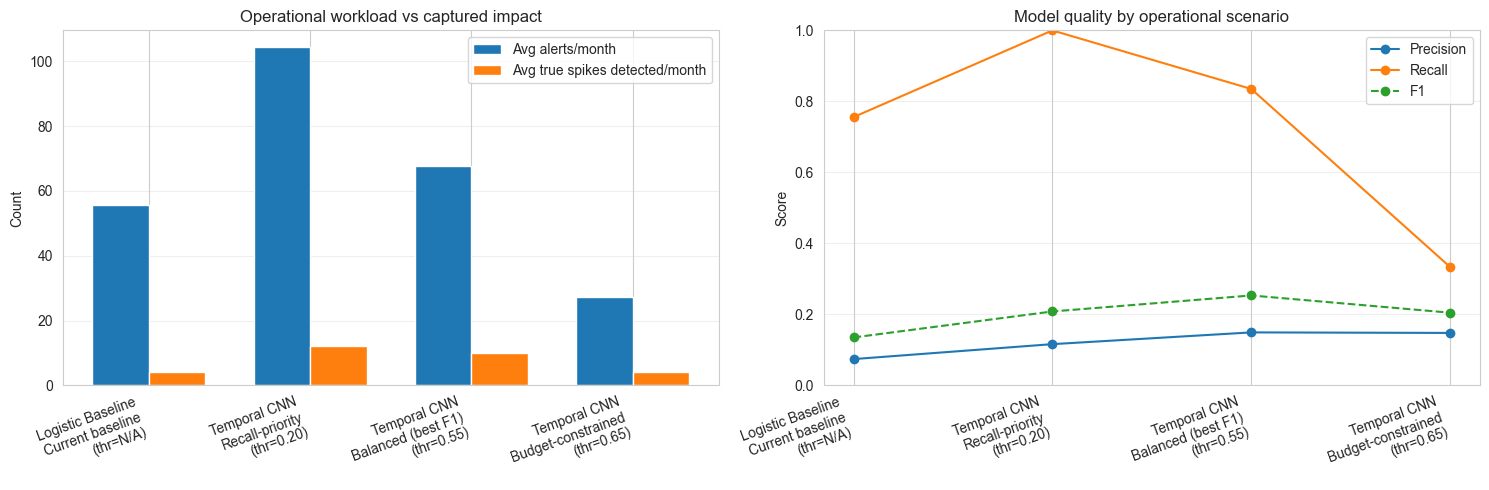

Highest recall option: Temporal CNN | Recall-priority (recall=1.000, alerts/month=104.3)
Lowest workload option: Temporal CNN | Budget-constrained (alerts/month=27.3, recall=0.333)


In [20]:
# Side-by-side operational insight plot
# Uses ops_df from previous cell

plot_df = ops_df.copy()
plot_df["label"] = plot_df["model"] + "\n" + plot_df["scenario"] + "\n(thr=" + plot_df["threshold"].astype(str) + ")"

x = np.arange(len(plot_df))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: workload vs impact
axes[0].bar(x - width/2, plot_df["alerts_per_month_avg"], width, label="Avg alerts/month")
axes[0].bar(x + width/2, plot_df["true_spikes_detected_per_month_avg"], width, label="Avg true spikes detected/month")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_df["label"], rotation=20, ha="right")
axes[0].set_ylabel("Count")
axes[0].set_title("Operational workload vs captured impact")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Panel 2: quality trade-off
axes[1].plot(x, plot_df["precision"], marker="o", label="Precision")
axes[1].plot(x, plot_df["recall"], marker="o", label="Recall")
axes[1].plot(x, plot_df["f1"], marker="o", linestyle="--", label="F1")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["label"], rotation=20, ha="right")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Score")
axes[1].set_title("Model quality by operational scenario")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Quick highlight statements
best_recall_row = plot_df.loc[plot_df["recall"].idxmax()]
lowest_load_row = plot_df.loc[plot_df["alerts_per_month_avg"].idxmin()]

print(
    f"Highest recall option: {best_recall_row['model']} | {best_recall_row['scenario']} "
    f"(recall={best_recall_row['recall']:.3f}, alerts/month={best_recall_row['alerts_per_month_avg']:.1f})"
)
print(
    f"Lowest workload option: {lowest_load_row['model']} | {lowest_load_row['scenario']} "
    f"(alerts/month={lowest_load_row['alerts_per_month_avg']:.1f}, recall={lowest_load_row['recall']:.3f})"
)